## LCA (H‑1B / H‑1B1 / E‑3) — FY2025 Q3 Analysis
本notebook分析了美国劳工局披露的2025财年截至Q3的LCA数据，时间范围包含：**2024年10月1日 - 2025年6月30日**
原始数据：
- 位置：data/LCA_Disclosure_Data_FY2025_Q3.xlsx
- 快速读取：data/LCA_Disclosure_Data_FY2025_Q3.parquet
- 来源：https://www.dol.gov/agencies/eta/foreign-labor/performance 
- 字段解释：data/LCA_Record_Layout_FY2025_Q3.pdf

## 0. Import & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)

In [3]:
# 导入utils模块
from lca_utils import *

In [4]:
import importlib, lca_utils
importlib.reload(lca_utils)

<module 'lca_utils' from 'c:\\Users\\elisa\\Desktop\\git\\codes\\data-analytics-portfolio\\LCA-Disclosure-Analysis\\lca_utils.py'>

In [5]:
# 路径设置
MAIN_PATH = Path("data/LCA_Disclosure_Data_FY2025_Q3.xlsx")
PARQUET_PATH = Path("data/LCA_Disclosure_Data_FY2025_Q3.parquet")

In [6]:
# # 预览
# main_preview = pd.read_excel(MAIN_PATH, nrows=10, dtype=str, engine="openpyxl")
# main_preview.head(10)

## 1. Read & Clean Data

In [ ]:
# # 读入完整文件
# main = pd.read_excel(MAIN_PATH, dtype=str, engine="openpyxl")

# # 列名标准化
# main.columns = [c.strip().upper() for c in main.columns]

# # 存为parquet文件
# for c in ["RECEIVED_DATE", "DECISION_DATE", "ORIGINAL_CERT_DATE", "BEGIN_DATE", "END_DATE"]:
#     if c in main.columns:
#         main[c] = pd.to_datetime(main[c], errors="coerce")

# main.to_parquet(PARQUET_PATH, engine="fastparquet", compression="snappy", index=False)
# print(f"Saved Parquet -> {PARQUET_PATH}")

In [7]:
# 从parquet文件读取，速度快
main = pd.read_parquet(PARQUET_PATH, engine="fastparquet")
main.head(5)

,CASE_NUMBER,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,ORIGINAL_CERT_DATE,VISA_CLASS,JOB_TITLE,SOC_CODE,SOC_TITLE,FULL_TIME_POSITION,BEGIN_DATE,END_DATE,TOTAL_WORKER_POSITIONS,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,NEW_CONCURRENT_EMPLOYMENT,CHANGE_EMPLOYER,AMENDED_PETITION,EMPLOYER_NAME,TRADE_NAME_DBA,EMPLOYER_ADDRESS1,EMPLOYER_ADDRESS2,EMPLOYER_CITY,EMPLOYER_STATE,EMPLOYER_POSTAL_CODE,EMPLOYER_COUNTRY,EMPLOYER_PROVINCE,EMPLOYER_PHONE,EMPLOYER_PHONE_EXT,EMPLOYER_FEIN,NAICS_CODE,EMPLOYER_POC_LAST_NAME,EMPLOYER_POC_FIRST_NAME,EMPLOYER_POC_MIDDLE_NAME,EMPLOYER_POC_JOB_TITLE,EMPLOYER_POC_ADDRESS1,EMPLOYER_POC_ADDRESS2,EMPLOYER_POC_CITY,EMPLOYER_POC_STATE,EMPLOYER_POC_POSTAL_CODE,EMPLOYER_POC_COUNTRY,EMPLOYER_POC_PROVINCE,EMPLOYER_POC_PHONE,EMPLOYER_POC_PHONE_EXT,EMPLOYER_POC_EMAIL,AGENT_REPRESENTING_EMPLOYER,AGENT_ATTORNEY_LAST_NAME,AGENT_ATTORNEY_FIRST_NAME,AGENT_ATTORNEY_MIDDLE_NAME,AGENT_ATTORNEY_ADDRESS1,AGENT_ATTORNEY_ADDRESS2,AGENT_ATTORNEY_CITY,AGENT_ATTORNEY_STATE,AGENT_ATTORNEY_POSTAL_CODE,AGENT_ATTORNEY_COUNTRY,AGENT_ATTORNEY_PROVINCE,AGENT_ATTORNEY_PHONE,AGENT_ATTORNEY_PHONE_EXT,AGENT_ATTORNEY_EMAIL_ADDRESS,LAWFIRM_NAME_BUSINESS_NAME,STATE_OF_HIGHEST_COURT,NAME_OF_HIGHEST_STATE_COURT,WORKSITE_WORKERS,SECONDARY_ENTITY,SECONDARY_ENTITY_BUSINESS_NAME,WORKSITE_ADDRESS1,WORKSITE_ADDRESS2,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,WAGE_RATE_OF_PAY_FROM,WAGE_RATE_OF_PAY_TO,WAGE_UNIT_OF_PAY,PREVAILING_WAGE,PW_UNIT_OF_PAY,PW_TRACKING_NUMBER,PW_WAGE_LEVEL,PW_OES_YEAR,PW_OTHER_SOURCE,PW_OTHER_YEAR,PW_SURVEY_PUBLISHER,PW_SURVEY_NAME,TOTAL_WORKSITE_LOCATIONS,AGREE_TO_LC_STATEMENT,H_1B_DEPENDENT,WILLFUL_VIOLATOR,SUPPORT_H1B,STATUTORY_BASIS,APPENDIX_A_ATTACHED,PUBLIC_DISCLOSURE,PREPARER_LAST_NAME,PREPARER_FIRST_NAME,PREPARER_MIDDLE_INITIAL,PREPARER_BUSINESS_NAME,PREPARER_EMAIL
0,I-200-25181-143446,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,Data Scientists,15-2051,Data Scientists,Y,2025-07-14,2028-07-13,1,0,0,0,0,1,0,"Urban Outfitters, Inc.",None,5000 South Broad Street,None,Philadelphia,PA,19112,UNITED STATES OF AMERICA,None,+12154544722,None,23-2003332,488190,Manning,Kristin,None,Manager of Global Mobility and Immigration,5000 South Broad Street,Suite 434,Philadelphia,PA,19112,UNITED STATES OF AMERICA,None,+12154544722,None,urbn@immigrationlaw.com,Yes,Yeaw,Jennifer,None,230 W. Monroe Street,Suite 2800,Chicago,IL,60606,UNITED STATES OF AMERICA,None,+13127226300,None,urbn@immigrationlaw.com,"Corporate Immigration Partners, P.C.",NC,Supreme Court,1,No,None,5000 South Broad Street,None,Philadelphia,PHILADELPHIA,PA,19112,175000,None,Year,136011,Year,None,IV,7/1/2024 - 6/30/2025,None,None,None,None,2,Yes,No,No,None,None,None,Disclose Business,Hashemi,Sophia,None,"Corporate Immigration Partners, P.C.",urbn@immigrationlaw.com
1,I-200-25181-141251,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,IT Technical Associate - Developer II,15-1242,Database Administrators,Y,2025-07-03,2028-07-02,1,1,0,0,0,0,0,Illinois Wesleyan University,None,1312 Park Street,None,Bloomington,IL,61702,UNITED STATES OF AMERICA,None,+13095561000,None,37-0662594,611310,FARLEY,Holly,None,Interim Provost and Vice President for Academi...,1301 - Ninth Street Hall,600 Lincoln Avenue,Charleston,IL,61920,UNITED STATES OF AMERICA,None,+12175817049,None,hrfarley@eiu.edu,Yes,Arkell,Thomas,J,"1001 North Main Street, Suite A",None,Bloomington,IL,61701,UNITED STATES OF AMERICA,None,+13098286241,None,admin@dunnlaw.com,"Dunn Law Firm, LLP",IL,Illinois Supreme Court,1,No,None,600 Lincoln Avenue,None,Charleston,COLES,IL,61938,54500,None,Year,50877,Year,None,I,7/1/2024 - 6/30/2025,None,None,None,None,1,Yes,No,No,None,None,None,Disclose Business,None,None,None,None,None
2,I-200-25181-142198,Withdrawn,2025-06-30,2025-06-30,NaT,H-1B,Research Associate,19-1021,Biochemists and Biophysicists,Y,2025-09-08,2026-09-07,1,1,0,0,0,0,0,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,UNIVERSITY OF PENNSYLVANIA,3935 Walnut Street,5th Floor,PHILADELPHIA,PA,19104,UNITED STA

In [8]:
# 添加统一计算的annual wage列
main = add_offered_wage_annual(main,
                               auto_annual_from_threshold=50000)

In [9]:
main = filter_wage_outliers(main)

In [10]:
main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478013 entries, 0 to 479004
Data columns (total 98 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   CASE_NUMBER                     478013 non-null  object        
 1   CASE_STATUS                     478013 non-null  object        
 2   RECEIVED_DATE                   478013 non-null  datetime64[ns]
 3   DECISION_DATE                   478013 non-null  datetime64[ns]
 4   ORIGINAL_CERT_DATE              21947 non-null   datetime64[ns]
 5   VISA_CLASS                      478013 non-null  object        
 6   JOB_TITLE                       478013 non-null  object        
 7   SOC_CODE                        478013 non-null  object        
 8   SOC_TITLE                       478013 non-null  object        
 9   FULL_TIME_POSITION              478013 non-null  object        
 10  BEGIN_DATE                      478013 non-null  datetime64[n

## 2. Analysis & Visualization

### 2.1 整体数据

In [11]:
# 整体申请数量
total_cases = main['CASE_NUMBER'].nunique()
print(f"Total number of cases submited: {total_cases}")

Total number of cases submited: 478013


In [12]:
# case对应的职位数量
print(f"Total positions applied: {main['TOTAL_WORKER_POSITIONS'].astype(int).sum()}")

Total positions applied: 782167


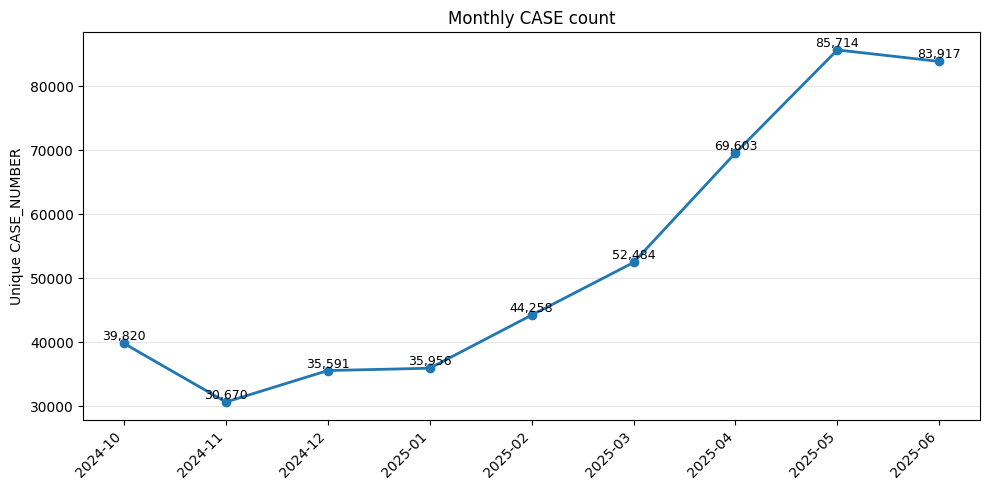

,CASE_COUNT
DECISION_MONTH,
2024-10,39820
2024-11,30670
2024-12,35591
2025-01,35956
2025-02,44258
2025-03,52484
2025-04,69603
2025-05,85714
2025-06,83917


In [13]:
# 申请数量，按月
plot_line_monthly_cases(main)

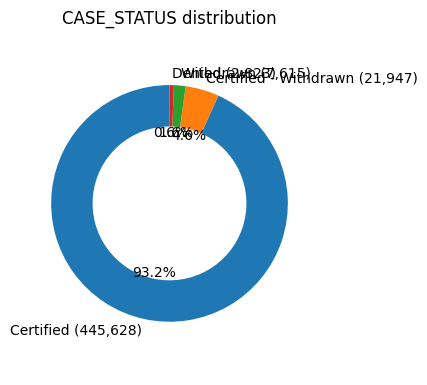

,count,pct
CASE_STATUS,,
Certified,445628,93.23
Certified - Withdrawn,21947,4.59
Withdrawn,7615,1.59
Denied,2823,0.59


In [14]:
# 申请状态分布
plot_donut_from_counts(main["CASE_STATUS"].value_counts(), 
                       title="CASE_STATUS distribution")

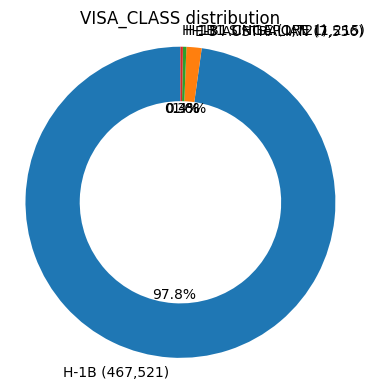

,count,pct
VISA_CLASS,,
H-1B,467521,97.81
E-3 AUSTRALIAN,7556,1.58
H-1B1 CHILE,1721,0.36
H-1B1 SINGAPORE,1215,0.25


In [15]:
# visa类别分布
plot_donut_from_counts(main["VISA_CLASS"].astype(str).str.upper().value_counts(), 
                       title="VISA_CLASS distribution")

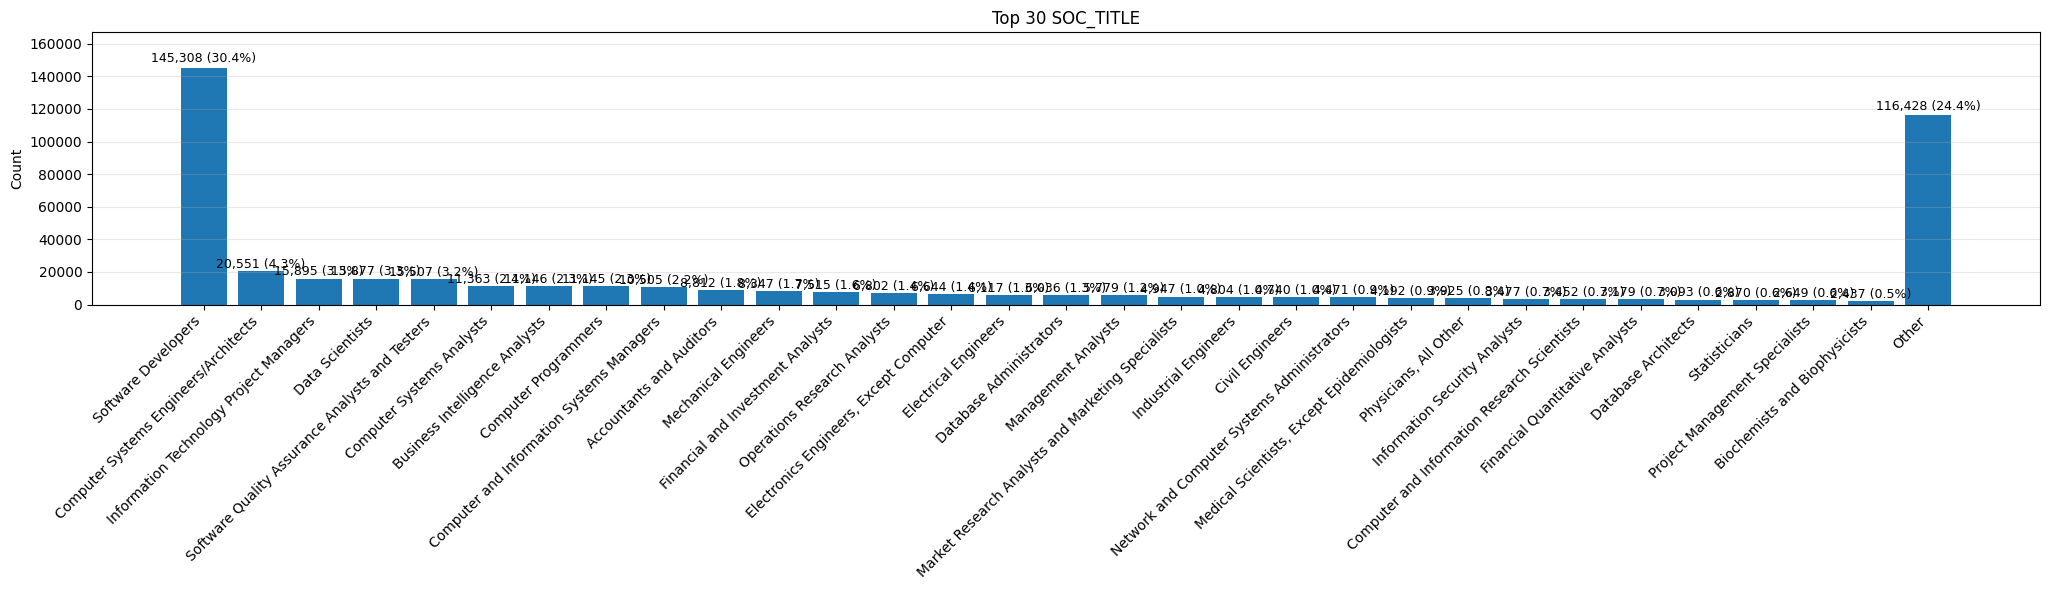

,count,pct
SOC_TITLE,,
Software Developers,145308,30.4
Computer Systems Engineers/Architects,20551,4.3
Information Technology Project Managers,15895,3.3
Data Scientists,15877,3.3
Software Quality Assurance Analysts and Testers,15507,3.2
Computer Systems Analysts,11363,2.4
Business Intelligence Analysts,11146,2.3
Computer Programmers,11145,2.3
Computer and Information Systems Managers,10505,2.2


In [16]:
# SOC_TITLE (标准化职位)分布，条形图
plot_bar_counts_vertical_simple(main["SOC_TITLE"], 
                                top_n=30, 
                                title="Top 30 SOC_TITLE")

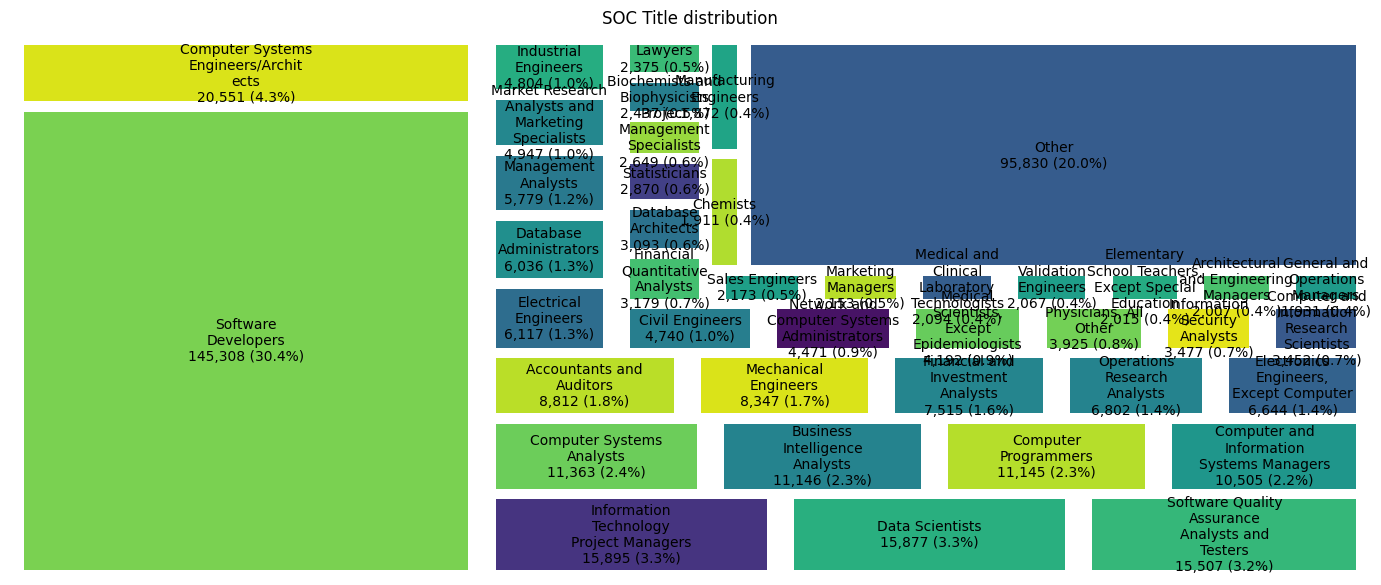

,count,pct
SOC_TITLE,,
Software Developers,145308,30.4
Computer Systems Engineers/Architects,20551,4.3
Information Technology Project Managers,15895,3.3
Data Scientists,15877,3.3
Software Quality Assurance Analysts and Testers,15507,3.2
Computer Systems Analysts,11363,2.4
Business Intelligence Analysts,11146,2.3
Computer Programmers,11145,2.3
Computer and Information Systems Managers,10505,2.2


In [17]:
# SOC_TITLE (标准化职位)分布，treemap
plot_treemap_from_series(main["SOC_TITLE"], top_n=40, title="SOC Title distribution")

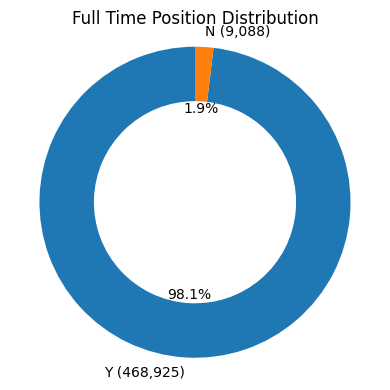

,count,pct
FULL_TIME_POSITION,,
Y,468925,98.1
N,9088,1.9


In [18]:
# 是否full time
plot_donut_from_counts(main['FULL_TIME_POSITION'].value_counts(), 
                       title='Full Time Position Distribution')

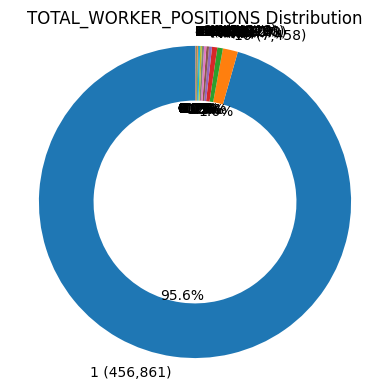

,count,pct
TOTAL_WORKER_POSITIONS,,
1,456861,95.58
10,7458,1.56
5,2748,0.57
3,2607,0.55
40,1476,0.31
2,1282,0.27
25,1129,0.24
20,1046,0.22
50,823,0.17


In [19]:
# case对应的职位数量分布
plot_donut_from_counts(main['TOTAL_WORKER_POSITIONS'].value_counts(), 
                       title='TOTAL_WORKER_POSITIONS Distribution')

,variable,nonzero_count,total_rows,pct_nonzero
0,NEW_EMPLOYMENT,182788,478013,38.2
1,CONTINUED_EMPLOYMENT,125412,478013,26.2
2,AMENDED_PETITION,78620,478013,16.4
3,CHANGE_EMPLOYER,74167,478013,15.5
4,CHANGE_PREVIOUS_EMPLOYMENT,39194,478013,8.2
5,NEW_CONCURRENT_EMPLOYMENT,2350,478013,0.5


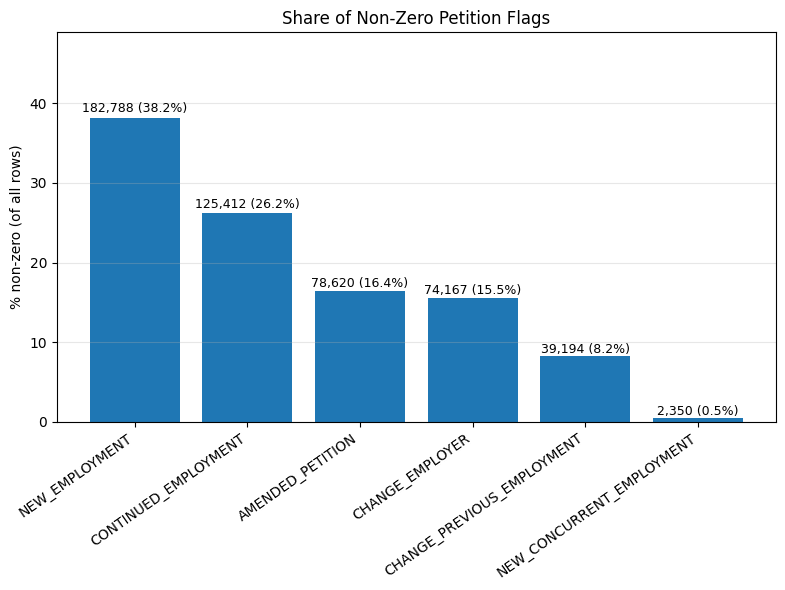

In [20]:
# Petition flags 非零占比
flags = ["NEW_EMPLOYMENT",
         "CONTINUED_EMPLOYMENT",
         "CHANGE_PREVIOUS_EMPLOYMENT",
         "NEW_CONCURRENT_EMPLOYMENT",
         "CHANGE_EMPLOYER",
         "AMENDED_PETITION"]

res_flags = nonzero_share(main, flags)
display(res_flags)
plot_nonzero_share_vertical(res_flags, title="Share of Non-Zero Petition Flags")

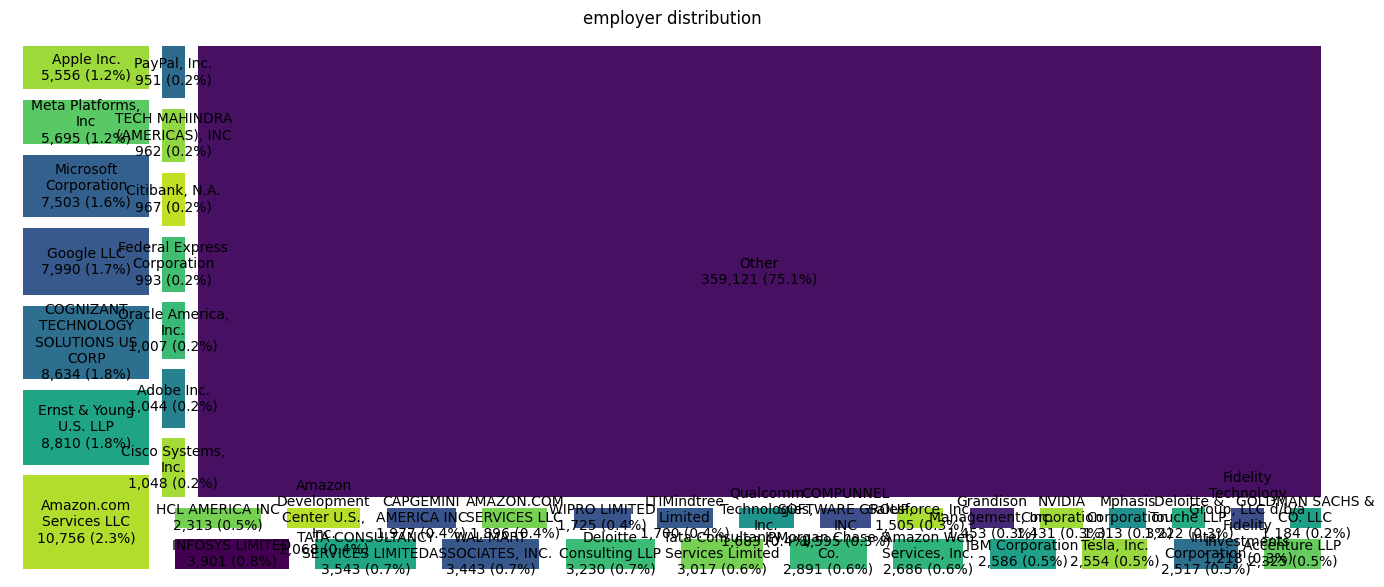

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,10756,2.3
Ernst & Young U.S. LLP,8810,1.8
COGNIZANT TECHNOLOGY SOLUTIONS US CORP,8634,1.8
Google LLC,7990,1.7
Microsoft Corporation,7503,1.6
"Meta Platforms, Inc",5695,1.2
Apple Inc.,5556,1.2
INFOSYS LIMITED,3901,0.8
TATA CONSULTANCY SERVICES LIMITED,3543,0.7


In [21]:
# 雇主分布
plot_treemap_from_series(main["EMPLOYER_NAME"], 
                         top_n=40, 
                         title="employer distribution")

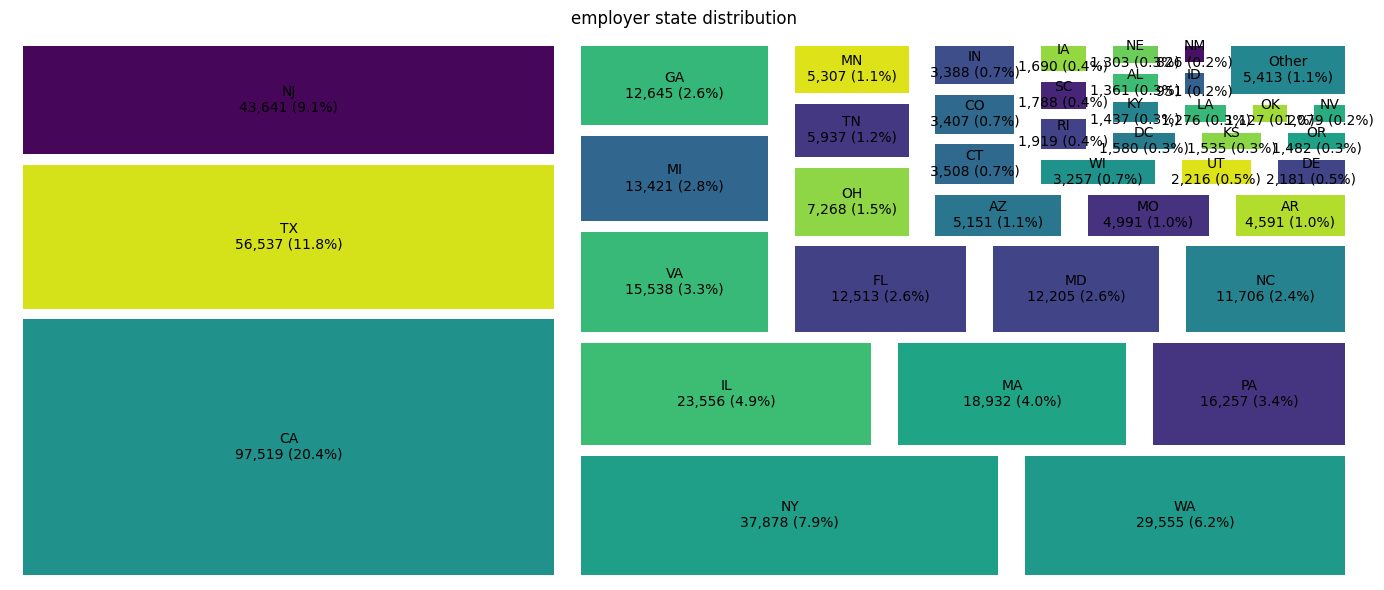

,count,pct
EMPLOYER_STATE,,
CA,97519,20.4
TX,56537,11.8
NJ,43641,9.1
NY,37878,7.9
WA,29555,6.2
IL,23556,4.9
MA,18932,4.0
PA,16257,3.4
VA,15538,3.3


In [22]:
# 雇主state分布
plot_treemap_from_series(main["EMPLOYER_STATE"], 
                         top_n=40, 
                         title="employer state distribution")

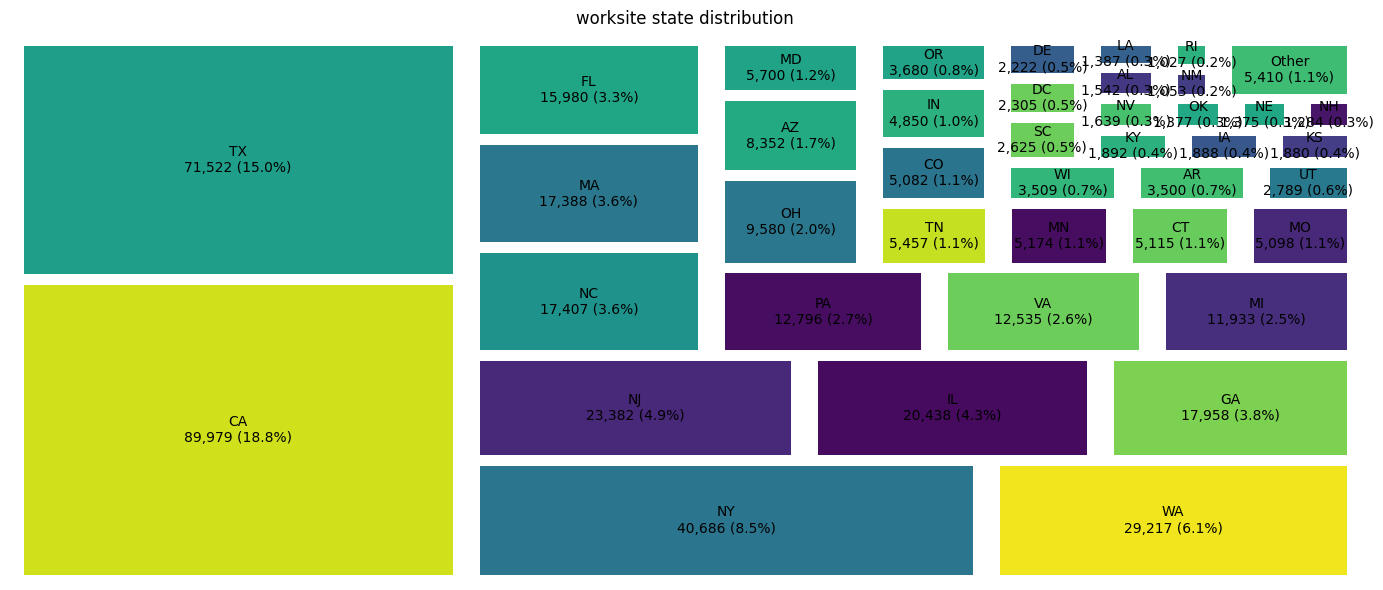

,count,pct
WORKSITE_STATE,,
CA,89979,18.8
TX,71522,15.0
NY,40686,8.5
WA,29217,6.1
NJ,23382,4.9
IL,20438,4.3
GA,17958,3.8
NC,17407,3.6
MA,17388,3.6


In [23]:
# worksite state 分布
plot_treemap_from_series(main["WORKSITE_STATE"], 
                         top_n=40, 
                         title="worksite state distribution")

In [24]:
# 年工资分布，分位数
deciles(series=main["OFFERED_WAGE_ANNUAL_USD"].dropna().astype(float),
        step=0.1)

,percentile,value
0,0,15080.04
1,10,71947.00
2,20,84094.00
3,30,95000.00
4,40,105997.00
5,50,117832.00
6,60,130000.00
7,70,146307.20
8,80,165322.66
9,90,195539.80


In [25]:
main['OFFERED_WAGE_ANNUAL_USD'].describe()

count    4.780130e+05
mean     1.288371e+05
std      7.312493e+04
min      1.508004e+04
25%      8.975000e+04
50%      1.178320e+05
75%      1.546160e+05
max      2.130000e+07
Name: OFFERED_WAGE_ANNUAL_USD, dtype: float64

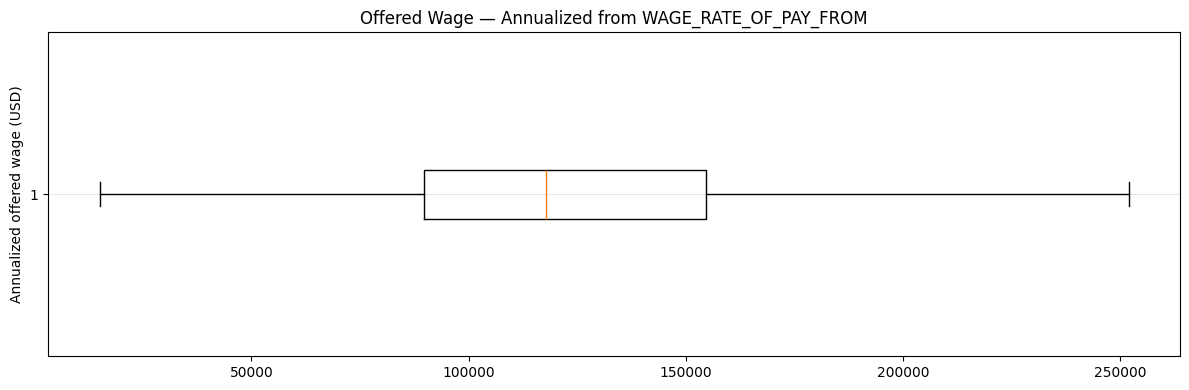

In [ ]:
# Boxplot（竖向）
plt.figure(figsize=(12, 4))
plt.boxplot(main['OFFERED_WAGE_ANNUAL_USD'], vert=False, showfliers=False)
plt.ylabel("Annualized offered wage (USD)")
plt.title("Offered Wage — Annualized from WAGE_RATE_OF_PAY_FROM")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

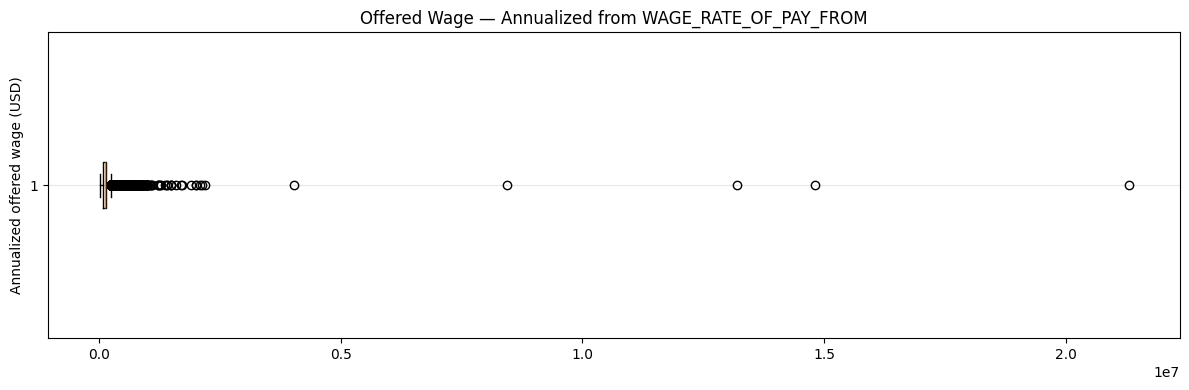

In [ ]:
# Boxplot（竖向），包含outliers
plt.figure(figsize=(12, 4))
plt.boxplot(main['OFFERED_WAGE_ANNUAL_USD'], vert=False, showfliers=True)  # 如需隐藏离群点，可改 showfliers=False
plt.ylabel("Annualized offered wage (USD)")
plt.title("Offered Wage — Annualized from WAGE_RATE_OF_PAY_FROM")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# 最高10/最低10工资的title类别
top10, bot10 = soc_median_tables(main, 
                                 wage_col="OFFERED_WAGE_ANNUAL_USD", 
                                 soc_col="SOC_TITLE", 
                                 min_count=500)
display(top10)
display(bot10)

,SOC_TITLE,n,median_annual
444,Hospitalists,1389,278012.80
400,General Internal Medicine Physicians,1095,240178.00
143,Chief Executives,743,229000.00
495,Lawyers,2375,225000.00
208,Computer and Information Systems Managers,10505,195000.00
357,Financial Managers,1399,190756.80
205,Computer and Information Research Scientists,3452,181030.00
261,"Dentists, General",847,180000.00
55,Architectural and Engineering Managers,2007,178000.00
529,Marketing Managers,2153,170605.24


,SOC_TITLE,n,median_annual
726,Rehabilitation Counselors,532,39145.6
99,Biological Technicians,799,55806.0
762,"Secondary School Teachers, Except Special and ...",1785,57238.0
570,"Middle School Teachers, Except Special and Car...",840,57460.0
313,"Elementary School Teachers, Except Special Edu...",2015,59878.0
563,Mental Health Counselors,531,65000.0
560,Medical and Clinical Laboratory Technologists,2094,66123.2
702,Public Relations Specialists,590,66530.0
113,"Business Operations Specialists, All Other",515,68296.0
608,Occupational Therapists,817,71968.0


In [35]:
depend_list = main[main['H_1B_DEPENDENT']=='Yes']['EMPLOYER_NAME'].unique().tolist()
print(f"# of companies that specifically depends on H1b: {len(depend_list)}")
print(depend_list[:20])

# of companies that specifically depends on H1b: 5253
['TATA CONSULTANCY SERVICES LIMITED', 'INFOTECH PRISM LLC', 'Bean Infosystems LLC', 'Radixlink, Inc.', 'IndSoft, Inc.', 'Apogee Medical Group, Delaware, Inc.', 'Neni TechSystems Inc ', 'RITE PROS, INC', 'COGNIZANT TECHNOLOGY SOLUTIONS US CORP', 'Mphasis Corporation', 'Prodapt North America, Inc.', 'Capgemini America Inc', 'Intone Networks, Inc.', 'Tata Consultancy Services Limited', 'Tekgroup LLC', 'Mphasis Corporation ', 'SERVESYS CORPORATION', 'Advanced Micro Devices, Inc.', 'IGATE Solutions LLC', 'Meta Platforms, Inc']


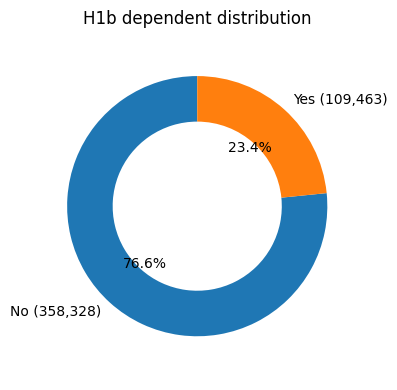

,count,pct
H_1B_DEPENDENT,,
No,358328,76.6
Yes,109463,23.4


In [34]:
plot_donut_from_counts(main['H_1B_DEPENDENT'].value_counts(), 
                       title='H1b dependent distribution')

In [36]:
support_list = main[main['SUPPORT_H1B']=='Yes']['EMPLOYER_NAME'].unique().tolist()
print(f"# of companies that specifically support H1b: {len(support_list)}")
print(support_list[:20])

# of companies that specifically support H1b: 5188
['TATA CONSULTANCY SERVICES LIMITED', 'INFOTECH PRISM LLC', 'Bean Infosystems LLC', 'Radixlink, Inc.', 'IndSoft, Inc.', 'Apogee Medical Group, Delaware, Inc.', 'Neni TechSystems Inc ', 'RITE PROS, INC', 'COGNIZANT TECHNOLOGY SOLUTIONS US CORP', 'Mphasis Corporation', 'Prodapt North America, Inc.', 'Capgemini America Inc', 'Intone Networks, Inc.', 'Tata Consultancy Services Limited', 'Tekgroup LLC', 'Mphasis Corporation ', 'SERVESYS CORPORATION', 'Advanced Micro Devices, Inc.', 'IGATE Solutions LLC', 'Meta Platforms, Inc']


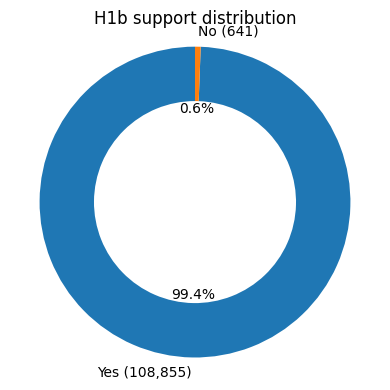

,count,pct
SUPPORT_H1B,,
Yes,108855,99.41
No,641,0.59


In [37]:
plot_donut_from_counts(main['SUPPORT_H1B'].value_counts(), 
                       title='H1b support distribution')

### 2.2 Data 岗位数据

In [38]:
# 筛选Data相关岗位
# 1) SOC_TITLE 精确匹配（大小写不敏感）
soc_targets = {s.casefold() for s in ["Data Scientists", "Business Intelligence Analysts"]}
mask_soc = main["SOC_TITLE"].astype(str).str.strip().str.casefold().isin(soc_targets)

# 2) JOB_TITLE 关键词子串匹配（大小写不敏感）
keywords = [
    "Data Analyst",
    "Data Scientist",
    "Data Science",
    "Business Analyst",
    "Data Analytics",
    "Advanced Analytics",
]
pattern = "|".join(re.escape(k) for k in keywords)
mask_job = main["JOB_TITLE"].astype(str).str.contains(pattern, case=False, na=False)

# 3) 合并条件并得到子集
data_subset = main[mask_soc | mask_job].copy()

In [39]:
# Data相关岗位申请数量
total_cases = data_subset['CASE_NUMBER'].nunique()
print(f"Total number of cases submited: {total_cases}")

Total number of cases submited: 33419


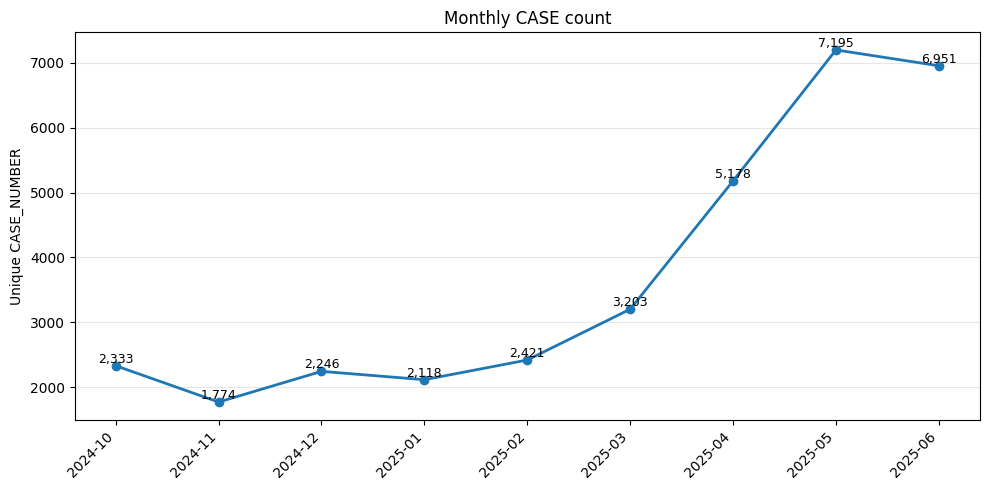

,CASE_COUNT
DECISION_MONTH,
2024-10,2333
2024-11,1774
2024-12,2246
2025-01,2118
2025-02,2421
2025-03,3203
2025-04,5178
2025-05,7195
2025-06,6951


In [42]:
# Data相关岗位申请数量，按月
plot_line_monthly_cases(data_subset)

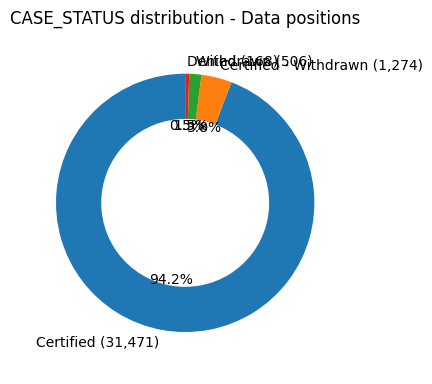

,count,pct
CASE_STATUS,,
Certified,31471,94.17
Certified - Withdrawn,1274,3.81
Withdrawn,506,1.51
Denied,168,0.50


In [43]:
# case状态分布
plot_donut_from_counts(data_subset["CASE_STATUS"].value_counts(), 
                       title="CASE_STATUS distribution - Data positions")

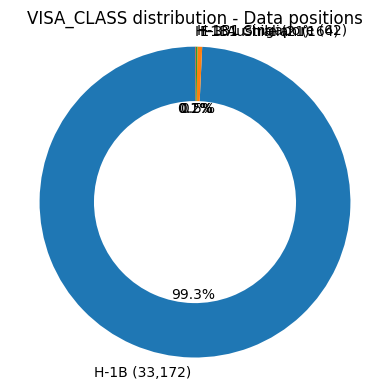

,count,pct
VISA_CLASS,,
H-1B,33172,99.26
E-3 Australian,164,0.49
H-1B1 Singapore,62,0.19
H-1B1 Chile,21,0.06


In [44]:
# visa类别
plot_donut_from_counts(data_subset["VISA_CLASS"].value_counts(), 
                       title="VISA_CLASS distribution - Data positions")

,variable,nonzero_count,total_rows,pct_nonzero
0,NEW_EMPLOYMENT,14895,33419,44.6
1,CONTINUED_EMPLOYMENT,7104,33419,21.3
2,CHANGE_EMPLOYER,5595,33419,16.7
3,AMENDED_PETITION,4437,33419,13.3
4,CHANGE_PREVIOUS_EMPLOYMENT,2460,33419,7.4
5,NEW_CONCURRENT_EMPLOYMENT,103,33419,0.3


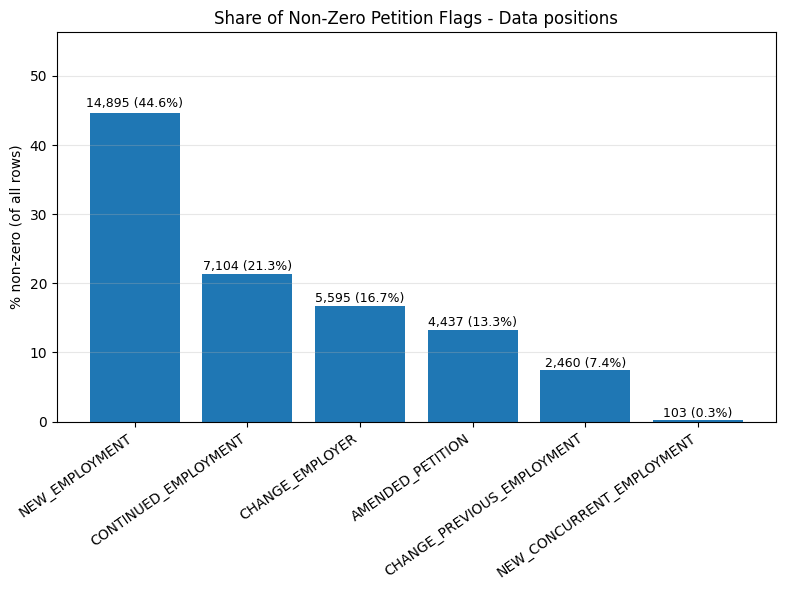

In [ ]:
# Petition flags 非零占比
flags = ["NEW_EMPLOYMENT",
         "CONTINUED_EMPLOYMENT",
         "CHANGE_PREVIOUS_EMPLOYMENT",
         "NEW_CONCURRENT_EMPLOYMENT",
         "CHANGE_EMPLOYER",
         "AMENDED_PETITION"]

res_flags = nonzero_share(data_subset, flags)
display(res_flags)
plot_nonzero_share_vertical(res_flags, 
                            title="Share of Non-Zero Petition Flags - Data positions")

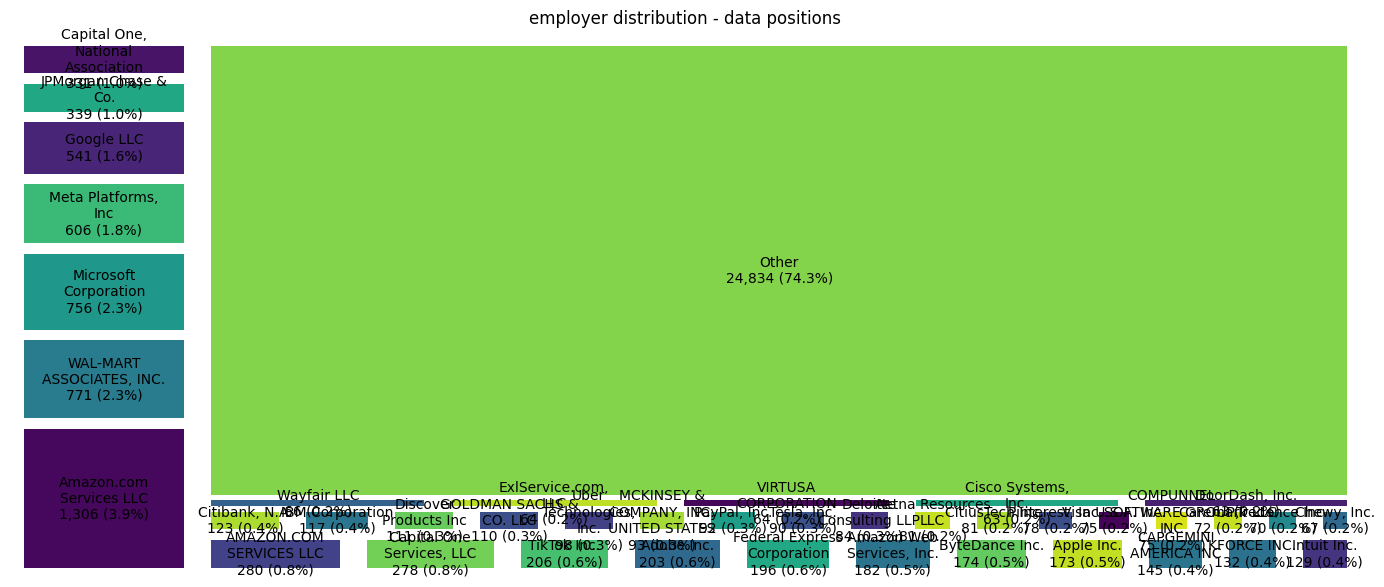

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,1306,3.9
"WAL-MART ASSOCIATES, INC.",771,2.3
Microsoft Corporation,756,2.3
"Meta Platforms, Inc",606,1.8
Google LLC,541,1.6
JPMorgan Chase & Co.,339,1.0
"Capital One, National Association",331,1.0
AMAZON.COM SERVICES LLC,280,0.8
"Capital One Services, LLC",278,0.8


In [46]:
# Data岗位雇主分布
plot_treemap_from_series(data_subset["EMPLOYER_NAME"], 
                         top_n=40, title="employer distribution - data positions")

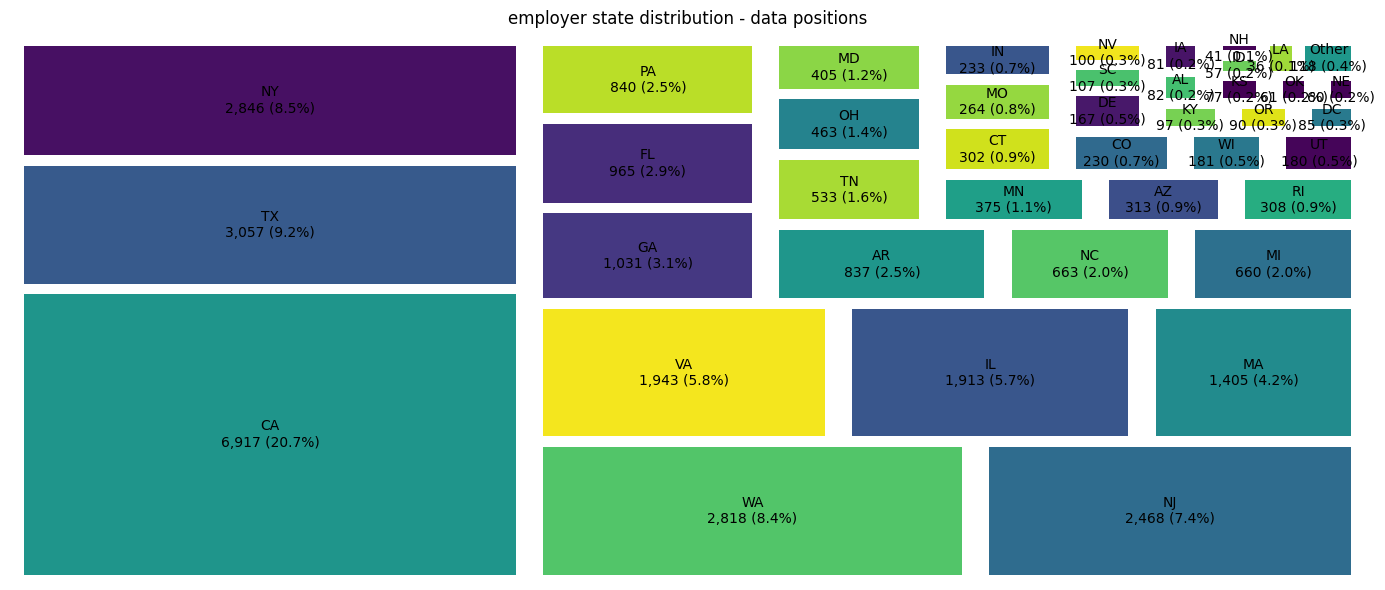

,count,pct
EMPLOYER_STATE,,
CA,6917,20.7
TX,3057,9.2
NY,2846,8.5
WA,2818,8.4
NJ,2468,7.4
VA,1943,5.8
IL,1913,5.7
MA,1405,4.2
GA,1031,3.1


In [47]:
# Data岗位雇主state 分布
plot_treemap_from_series(data_subset["EMPLOYER_STATE"], 
                               top_n=40, title="employer state distribution - data positions")

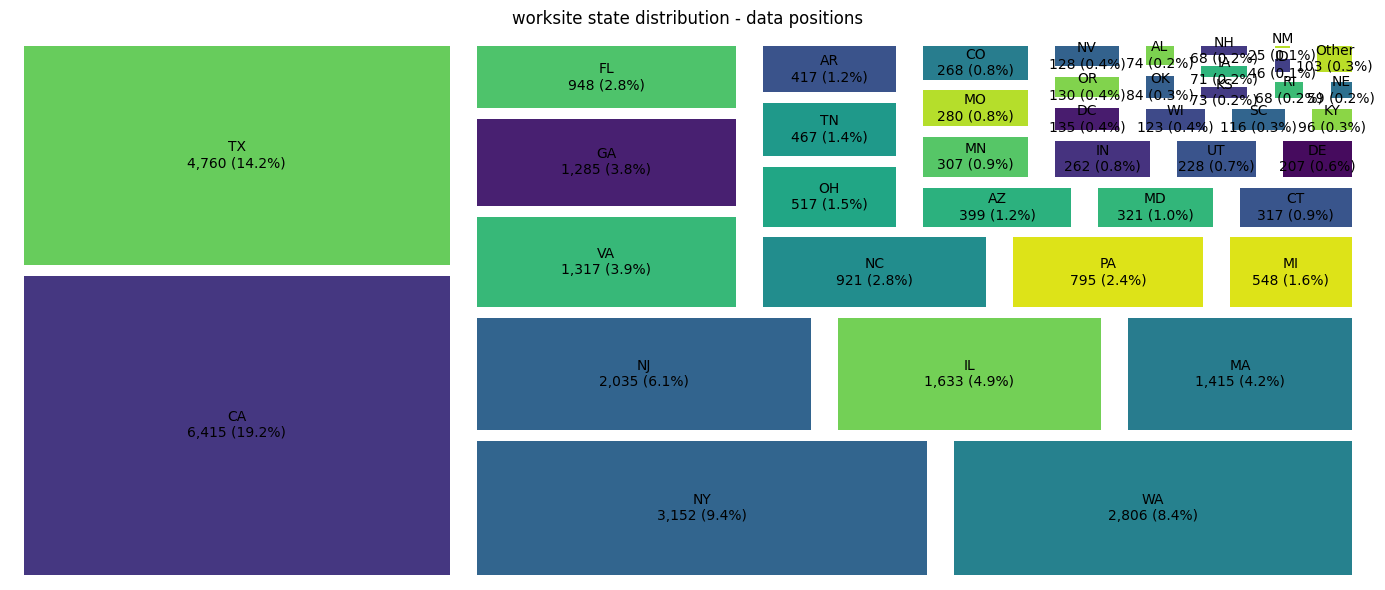

,count,pct
WORKSITE_STATE,,
CA,6415,19.2
TX,4760,14.2
NY,3152,9.4
WA,2806,8.4
NJ,2035,6.1
IL,1633,4.9
MA,1415,4.2
VA,1317,3.9
GA,1285,3.8


In [48]:
# Data岗位工作地点 state 分布
plot_treemap_from_series(data_subset["WORKSITE_STATE"], 
                         top_n=40, title="worksite state distribution - data positions")

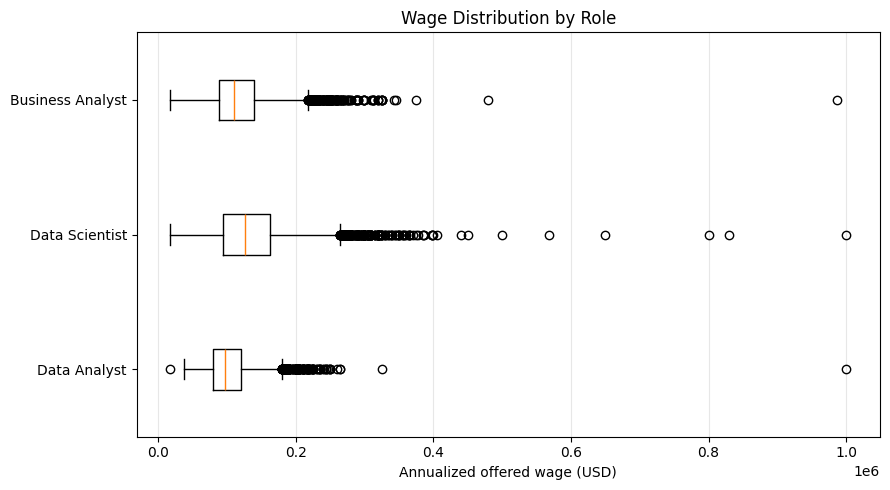

,Data Analyst,Data Scientist,Business Analyst
percentile,,,
0,18000.0,18000.00,18000.0
10,68640.0,81078.00,75000.0
20,76981.0,92040.00,83200.0
30,83000.0,102828.00,92040.0
40,90854.0,113693.00,100000.0
50,96900.0,126297.25,110739.0
60,105997.0,140000.00,118450.0
70,114000.0,154000.00,130669.0
80,127443.0,170668.80,146600.0


In [ ]:
# 计算da/ds/ba三个工种的工资分布
groups = role_wage_arrays(main, wage_col="OFFERED_WAGE_ANNUAL_USD")
plot_box_horizontal_from_groups(groups, title="Wage Distribution by Role")
tbl_deciles = role_deciles_table(main, wage_col="OFFERED_WAGE_ANNUAL_USD", step=0.10)
display(tbl_deciles)

#### 2.2.1 Data & Change Employer

In [ ]:
# 筛选数据岗位跳槽的记录
data_subset['CHANGE_EMPLOYER'] = data_subset['CHANGE_EMPLOYER'].astype(int)
data_chg_emp = data_subset[data_subset['CHANGE_EMPLOYER']>0]

In [59]:
# Data跳槽岗位申请数量
total_cases = data_chg_emp['CASE_NUMBER'].nunique()
print(f"Total number of cases submited: {total_cases}")

Total number of cases submited: 5595


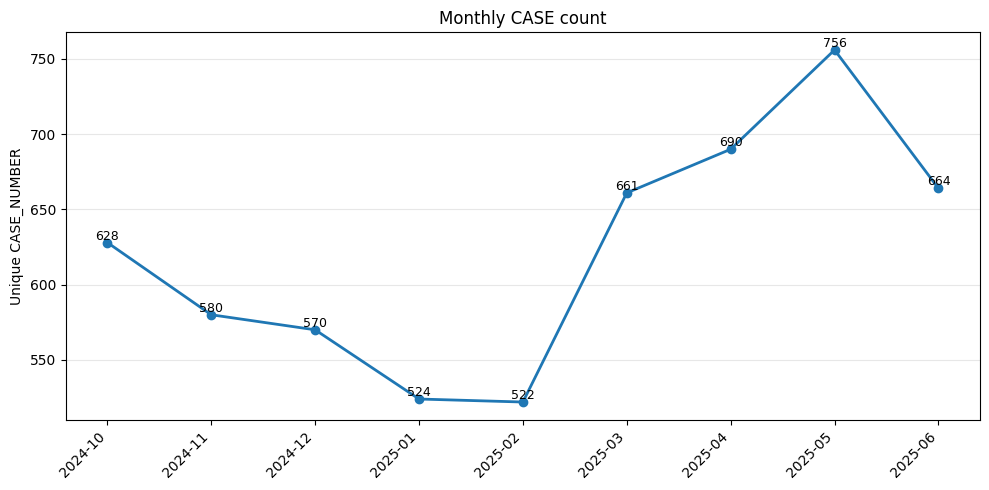

,CASE_COUNT
DECISION_MONTH,
2024-10,628
2024-11,580
2024-12,570
2025-01,524
2025-02,522
2025-03,661
2025-04,690
2025-05,756
2025-06,664


In [52]:
# Data跳槽岗位申请数量，按月
plot_line_monthly_cases(data_chg_emp)

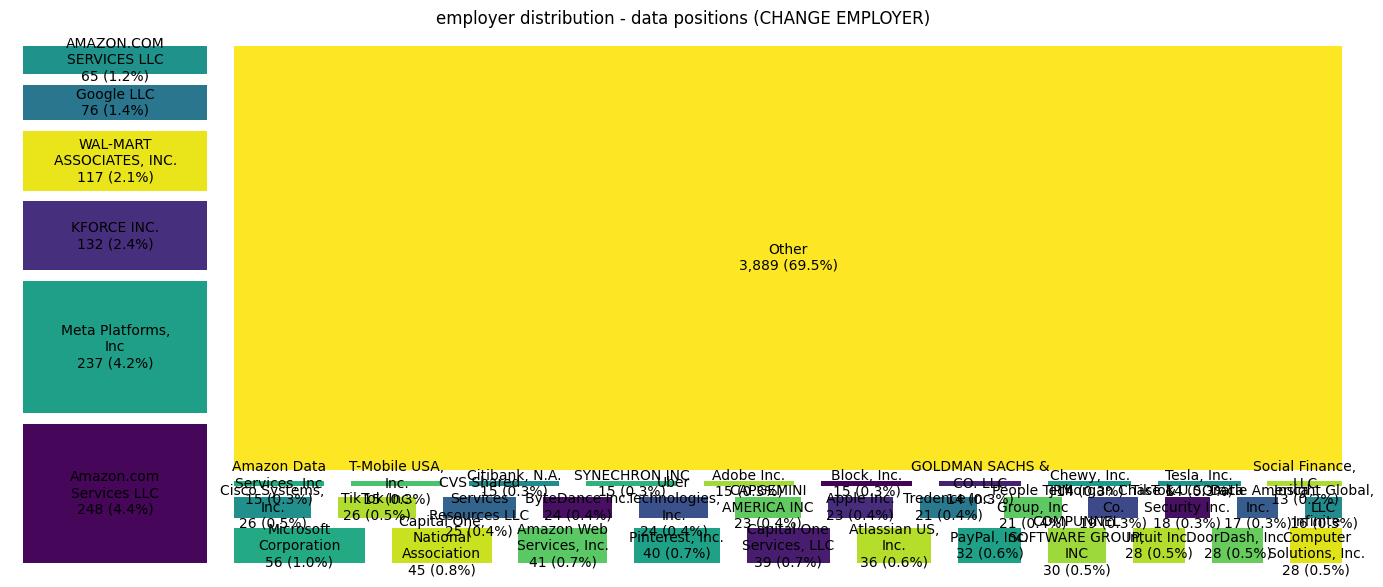

,count,pct
EMPLOYER_NAME,,
Amazon.com Services LLC,248,4.4
"Meta Platforms, Inc",237,4.2
KFORCE INC.,132,2.4
"WAL-MART ASSOCIATES, INC.",117,2.1
Google LLC,76,1.4
AMAZON.COM SERVICES LLC,65,1.2
Microsoft Corporation,56,1.0
"Capital One, National Association",45,0.8
"Amazon Web Services, Inc.",41,0.7


In [ ]:
# Data跳槽岗位雇主分布
plot_treemap_from_series(data_chg_emp["EMPLOYER_NAME"], 
                         top_n=40, title="employer distribution - data positions (CHANGE EMPLOYER)")

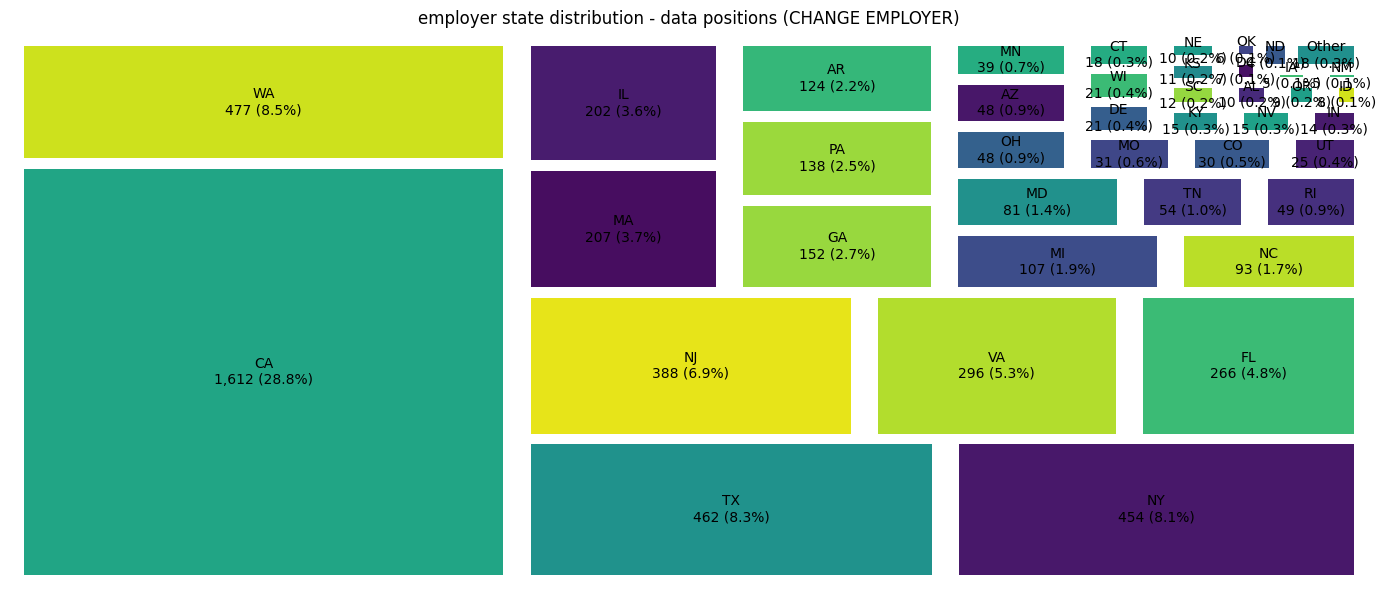

,count,pct
EMPLOYER_STATE,,
CA,1612,28.8
WA,477,8.5
TX,462,8.3
NY,454,8.1
NJ,388,6.9
VA,296,5.3
FL,266,4.8
MA,207,3.7
IL,202,3.6


In [54]:
# Data跳槽岗位雇主state 分布
plot_treemap_from_series(data_chg_emp["EMPLOYER_STATE"], 
                               top_n=40, title="employer state distribution - data positions (CHANGE EMPLOYER)")

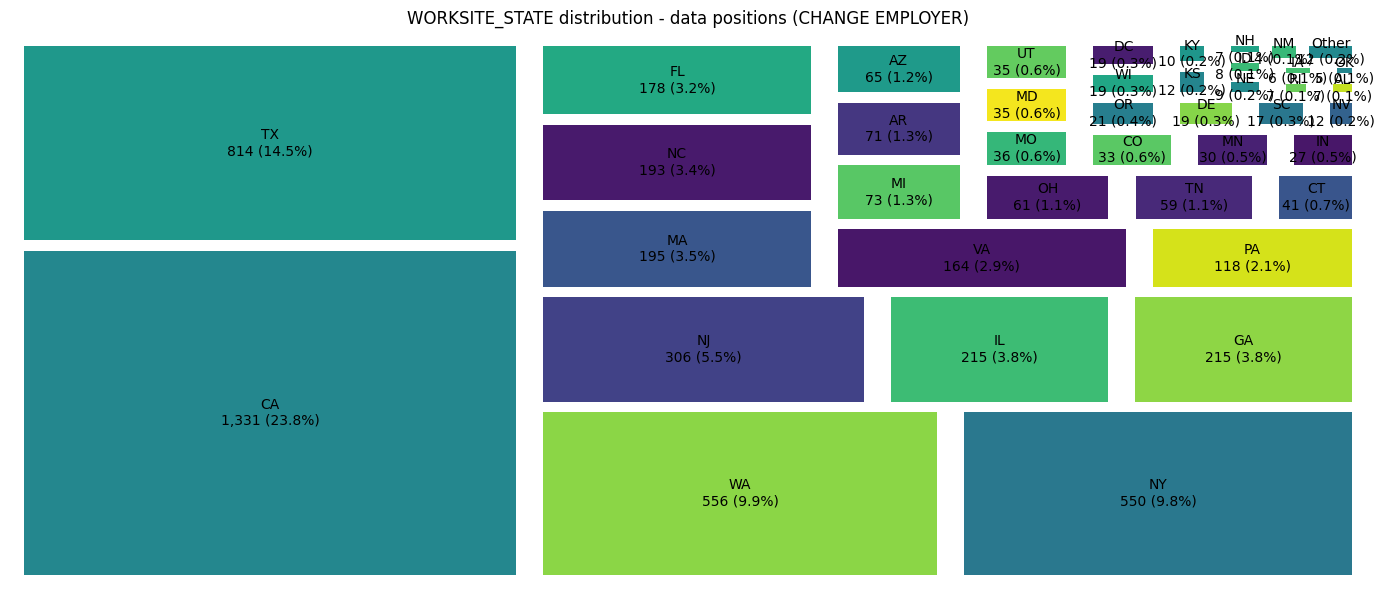

,count,pct
WORKSITE_STATE,,
CA,1331,23.8
TX,814,14.5
WA,556,9.9
NY,550,9.8
NJ,306,5.5
IL,215,3.8
GA,215,3.8
MA,195,3.5
NC,193,3.4


In [55]:
# Data跳槽岗位工作state 分布
plot_treemap_from_series(data_chg_emp["WORKSITE_STATE"], 
                               top_n=40, title="WORKSITE_STATE distribution - data positions (CHANGE EMPLOYER)")

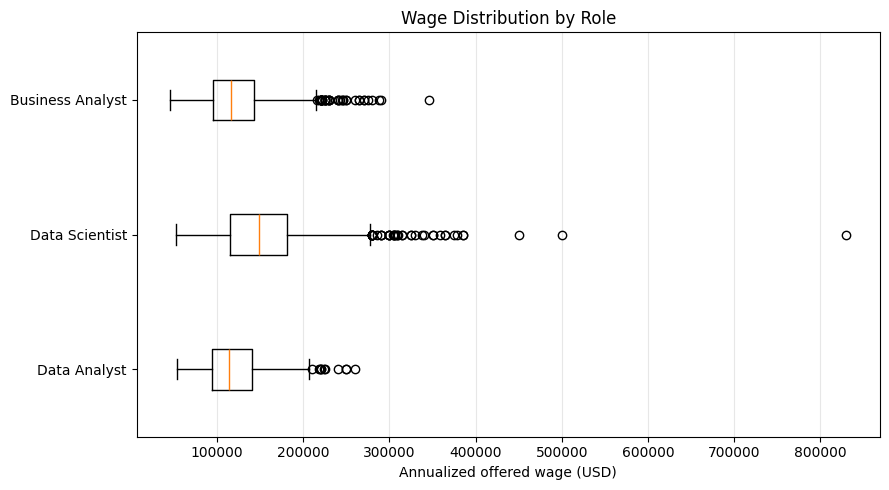

,Data Analyst,Data Scientist,Business Analyst
percentile,,,
0,54038.0,52042.0,45802.0
10,81557.0,92040.0,82713.2
20,92040.0,110739.0,92000.0
30,99700.0,120000.0,100000.0
40,106645.6,135000.0,110000.0
50,113974.5,148699.0,116480.0
60,123262.4,160000.0,125819.0
70,134493.0,175000.0,139268.4
80,145000.0,190000.0,150000.0


In [56]:
# 计算da/ds/ba三个工种的工资分布
groups = role_wage_arrays(data_chg_emp, wage_col="OFFERED_WAGE_ANNUAL_USD")
plot_box_horizontal_from_groups(groups, title="Wage Distribution by Role")
tbl_deciles = role_deciles_table(data_chg_emp, wage_col="OFFERED_WAGE_ANNUAL_USD", step=0.10)
display(tbl_deciles)

In [58]:
data_chg_emp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5595 entries, 0 to 478889
Data columns (total 98 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   CASE_NUMBER                     5595 non-null   object        
 1   CASE_STATUS                     5595 non-null   object        
 2   RECEIVED_DATE                   5595 non-null   datetime64[ns]
 3   DECISION_DATE                   5595 non-null   datetime64[ns]
 4   ORIGINAL_CERT_DATE              272 non-null    datetime64[ns]
 5   VISA_CLASS                      5595 non-null   object        
 6   JOB_TITLE                       5595 non-null   object        
 7   SOC_CODE                        5595 non-null   object        
 8   SOC_TITLE                       5595 non-null   object        
 9   FULL_TIME_POSITION              5595 non-null   object        
 10  BEGIN_DATE                      5595 non-null   datetime64[ns]
 11  END_DAT